# 3.2 Clustering Model Selection

**Objective:** Evaluate and select the best clustering configuration for job postings using the v6 feature matrix.

**Workflow:**
- Dataset preparation is handled by `src/data/prepare_clustering_dataset.py`
- Model training (sweeps + artifact logging) is handled by `src/models/clustering.py`
- This notebook documents the pipeline, shows sweep results, and selects the final model configuration

**Algorithms:**
- K-Means (sweep k = 2 → 66, step 4)
- HDBSCAN (sweep min_cluster_size ∈ {500, 750, 1000, 1250, 1500})

**Evaluation metrics (internal, no ground truth):**
- Silhouette Score — higher is better
- Calinski-Harabasz Index — higher is better
- Davies-Bouldin Index — lower is better
- Inertia — K-Means only, used for elbow analysis

## 1. Data Preparation — `prepare_clustering_dataset.py`


The v6 feature matrix is produced by `src/data/prepare_clustering_dataset.py`. The script does the following:

**1. Merge v5 train + test into one dataset**  
Clustering is unsupervised, so there is no need for a train/test split. Both halves of v5 are concatenated into a single ~123k-row matrix.

**2. Salary imputation via regression**  
Previous versions dropped rows with missing `normalized_salary` or filled them with the median, leaving a noisy salary signal.  
The script loads the best salary regression model from MLflow (run `1b6a1be9`) — a LightGBM model trained on all available features — and uses it to predict salary for the ~30% of rows where it is missing.  
This improved salary imputation quality from **MAE ≈ 30,000 → ≈ 26,000**, giving the clustering algorithm a much cleaner continuous signal.

**3. Output: `data/processed/v6/feature_matrix.csv`**  
A single file, no split, with salary fully imputed. This is the input to all clustering runs.

Inside `clustering.py → load_and_prepare()`, the matrix is then:
- Columns with high missingness (`log_applies`, `apply_rate`) and geography encodings (`state_salary_enc`, `fips_salary_enc`) are dropped
- Remaining NaNs are filled with the column median (`SimpleImputer`)
- All features are standardised to zero mean and unit variance (`StandardScaler`)

## 2. Model Training — `clustering.py`


All training runs are executed via `src/models/clustering.py → run_clustering()` and logged to the MLflow experiment **`clustering-analysis`**.

### K-Means sweep
```
K_RANGE = range(2, 70, 4)   # k ∈ {2, 6, 10, …, 66}
```
Each run logs: inertia, silhouette, Davies-Bouldin, Calinski-Harabasz.  
Runs with k ≤ 50 also log artefacts: word clouds (title + description), feature distribution box plots, `cluster_profiles.csv`, and per-cluster representative jobs (5 rows closest to centroid).

### HDBSCAN sweep
```
HDBSCAN_MIN_CLUSTER_SIZES = [500, 750, 1000, 1250, 1500]
min_samples = 10  (fixed)
```
Each run logs the same metric set plus `n_noise` / `noise_ratio`.  
Same artefacts are logged when the resulting cluster count ≤ 50.

## 3. K-Means Sweep — Elbow & Silhouette

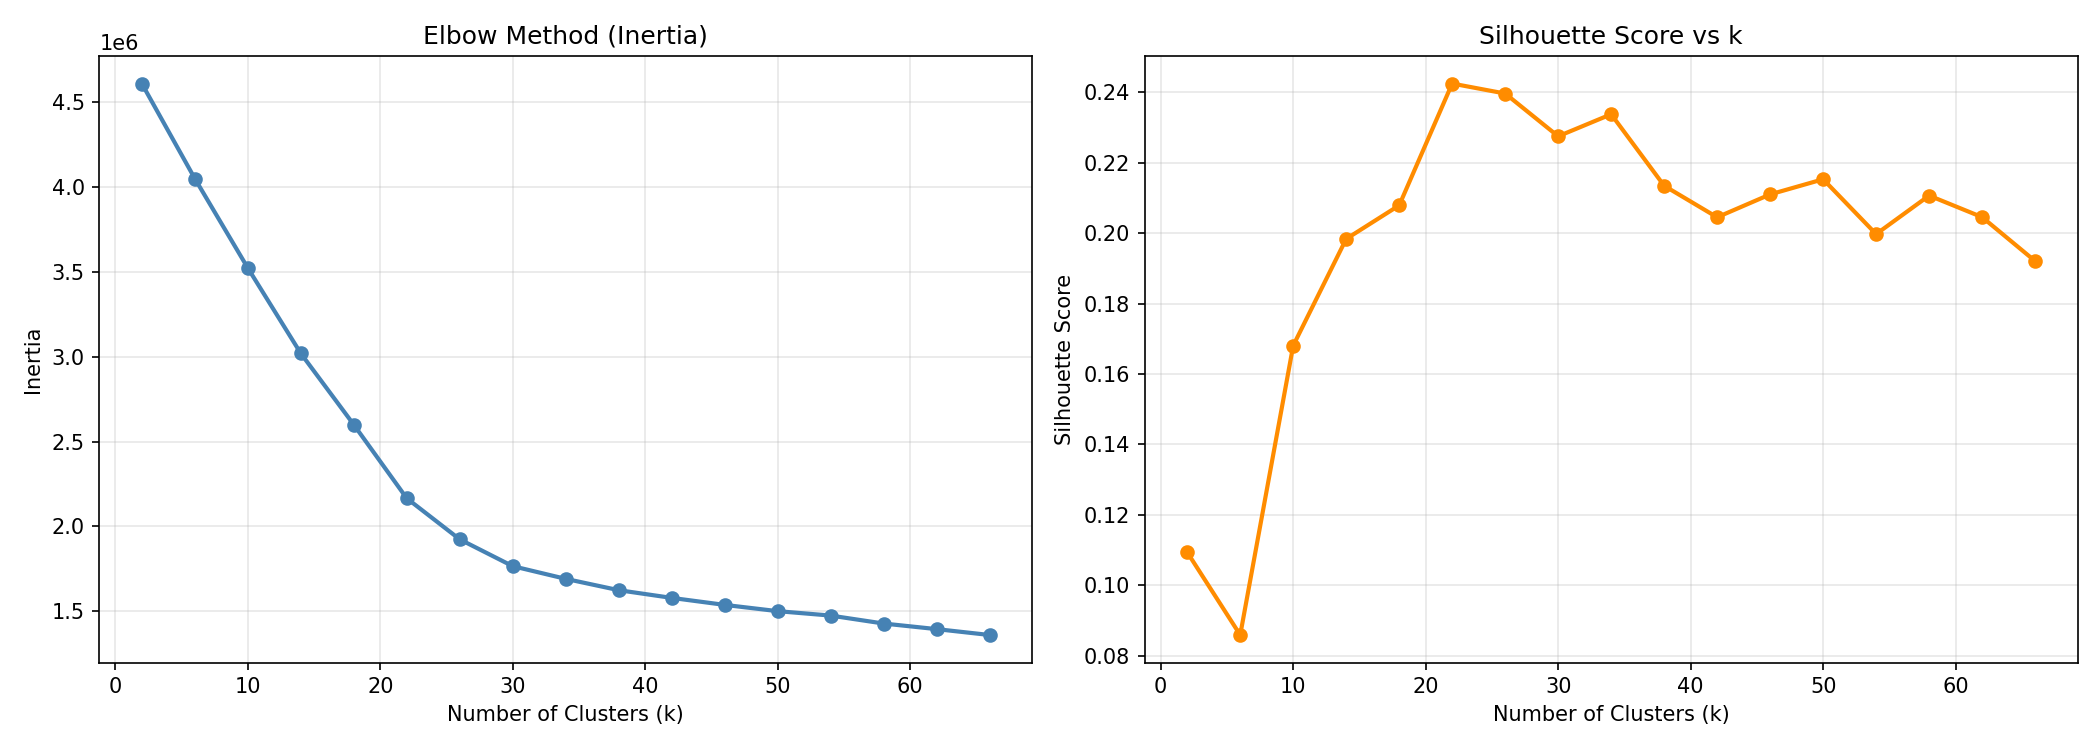

In [16]:
from IPython.display import Image, display
display(Image("../artifacts/kmeans_sweep.png"))

## 4. HDBSCAN Sweep — Cluster Count & Noise Ratio

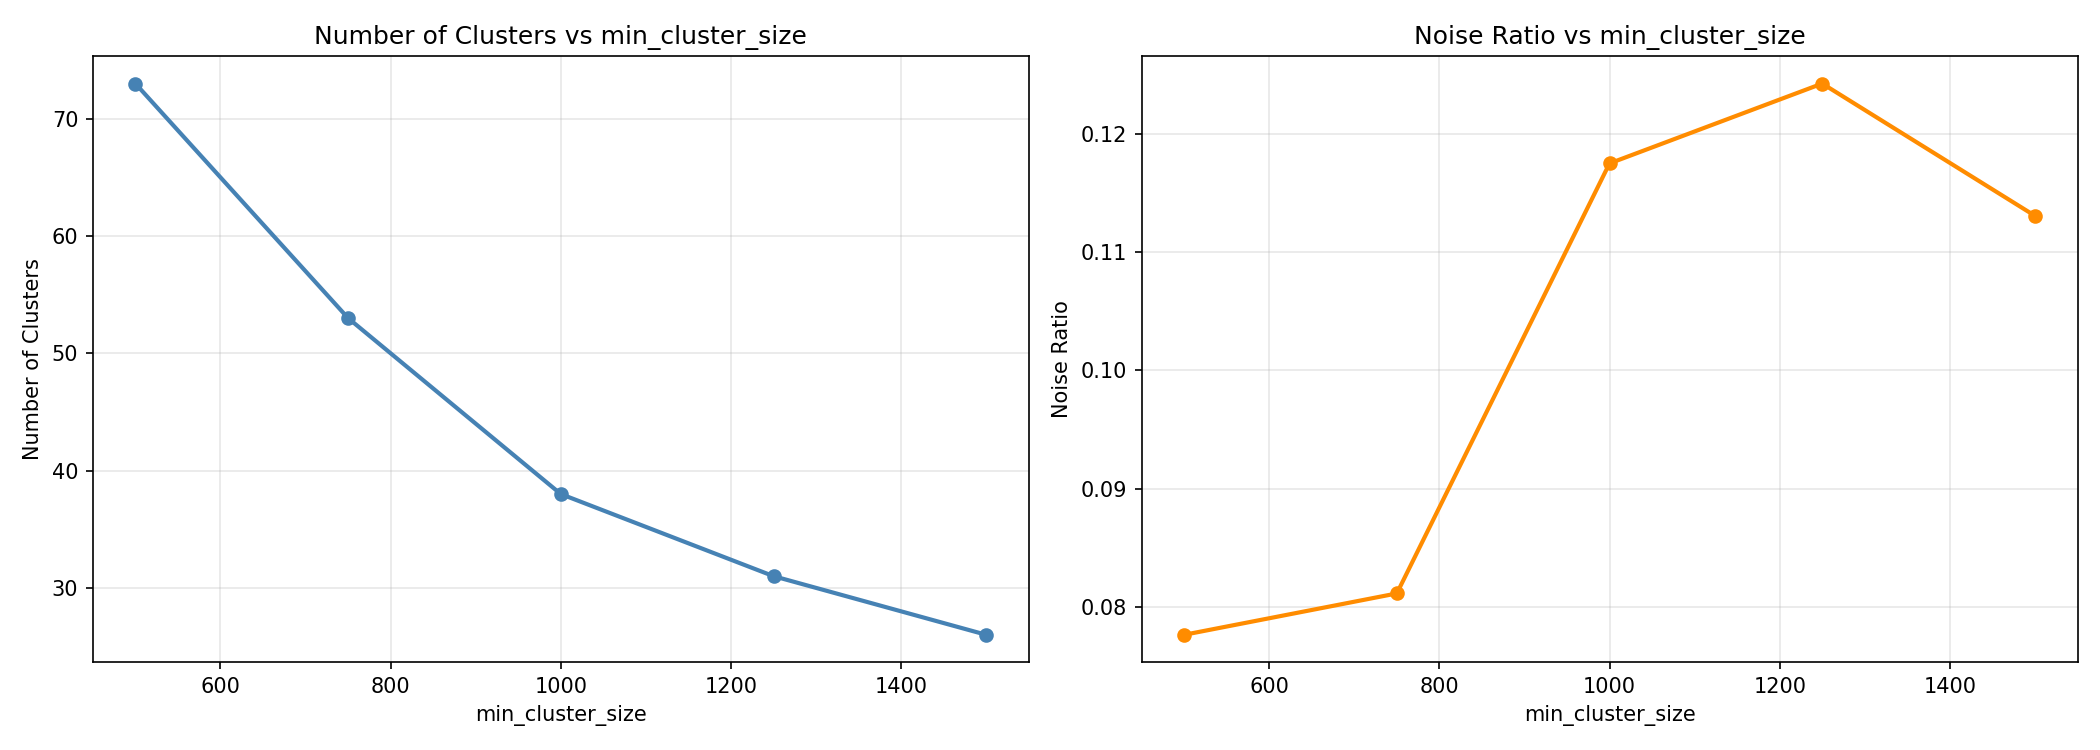

In [17]:
from IPython.display import Image, display
display(Image("../artifacts/hdbscan_sweep.png"))

## 5. Choosing the Final Configuration

Comparing candidate runs across internal metrics. KMeans runs in **blue**, HDBSCAN in **orange**.

In [18]:
import sys
import mlflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sys.path.append("../src")
from models.tracking.config import configure_mlflow

configure_mlflow(experiment_name="clustering-analysis")

%matplotlib inline

Experiment 'clustering-analysis' (id=3) has artifact_location='file:C:/Users/ognjen.vujovic/Desktop/job-intelligence/job-intelligence/mlruns/3' which is outside the repo root. Delete and recreate the experiment to fix artifact storage location.


In [23]:

RUNS = {
    "2fd4c772fe864a248490a7fc662bc6b9": {"label": "KMeans k=26",   "model": "kmeans"},
    "84324de9cb5d4a1f9d30e5a97e7c9c5c": {"label": "KMeans k=22",   "model": "kmeans"},
    "305d16c5414c438bb2f7839f57b55f11": {"label": "KMeans k=26 v2","model": "kmeans"},
    "9c4a7d932cb24e7b92a76f0a03b7ed84": {"label": "HDBSCAN mcs=1500","model": "hdbscan"},
    "8c929063b2a944c8ad2d52ed5efc6627": {"label": "HDBSCAN mcs=1250","model": "hdbscan"},
    "9f06bee954ab4838ae35adab542d0a17": {"label": "HDBSCAN mcs=1000","model": "hdbscan"},
}

client = mlflow.tracking.MlflowClient()
rows = []
for run_id, meta in RUNS.items():
    r = client.get_run(run_id)
    rows.append({
        "run_id":           run_id,
        "label":            meta["label"],
        "model":            meta["model"],
        "n_clusters":       r.data.metrics.get("n_clusters"),
        "silhouette":       r.data.metrics.get("silhouette"),
        "davies_bouldin":   r.data.metrics.get("davies_bouldin"),
        "calinski_harabasz":r.data.metrics.get("calinski_harabasz"),
        "noise_ratio":      r.data.metrics.get("noise_ratio", 0.0),
    })

df_runs = pd.DataFrame(rows)

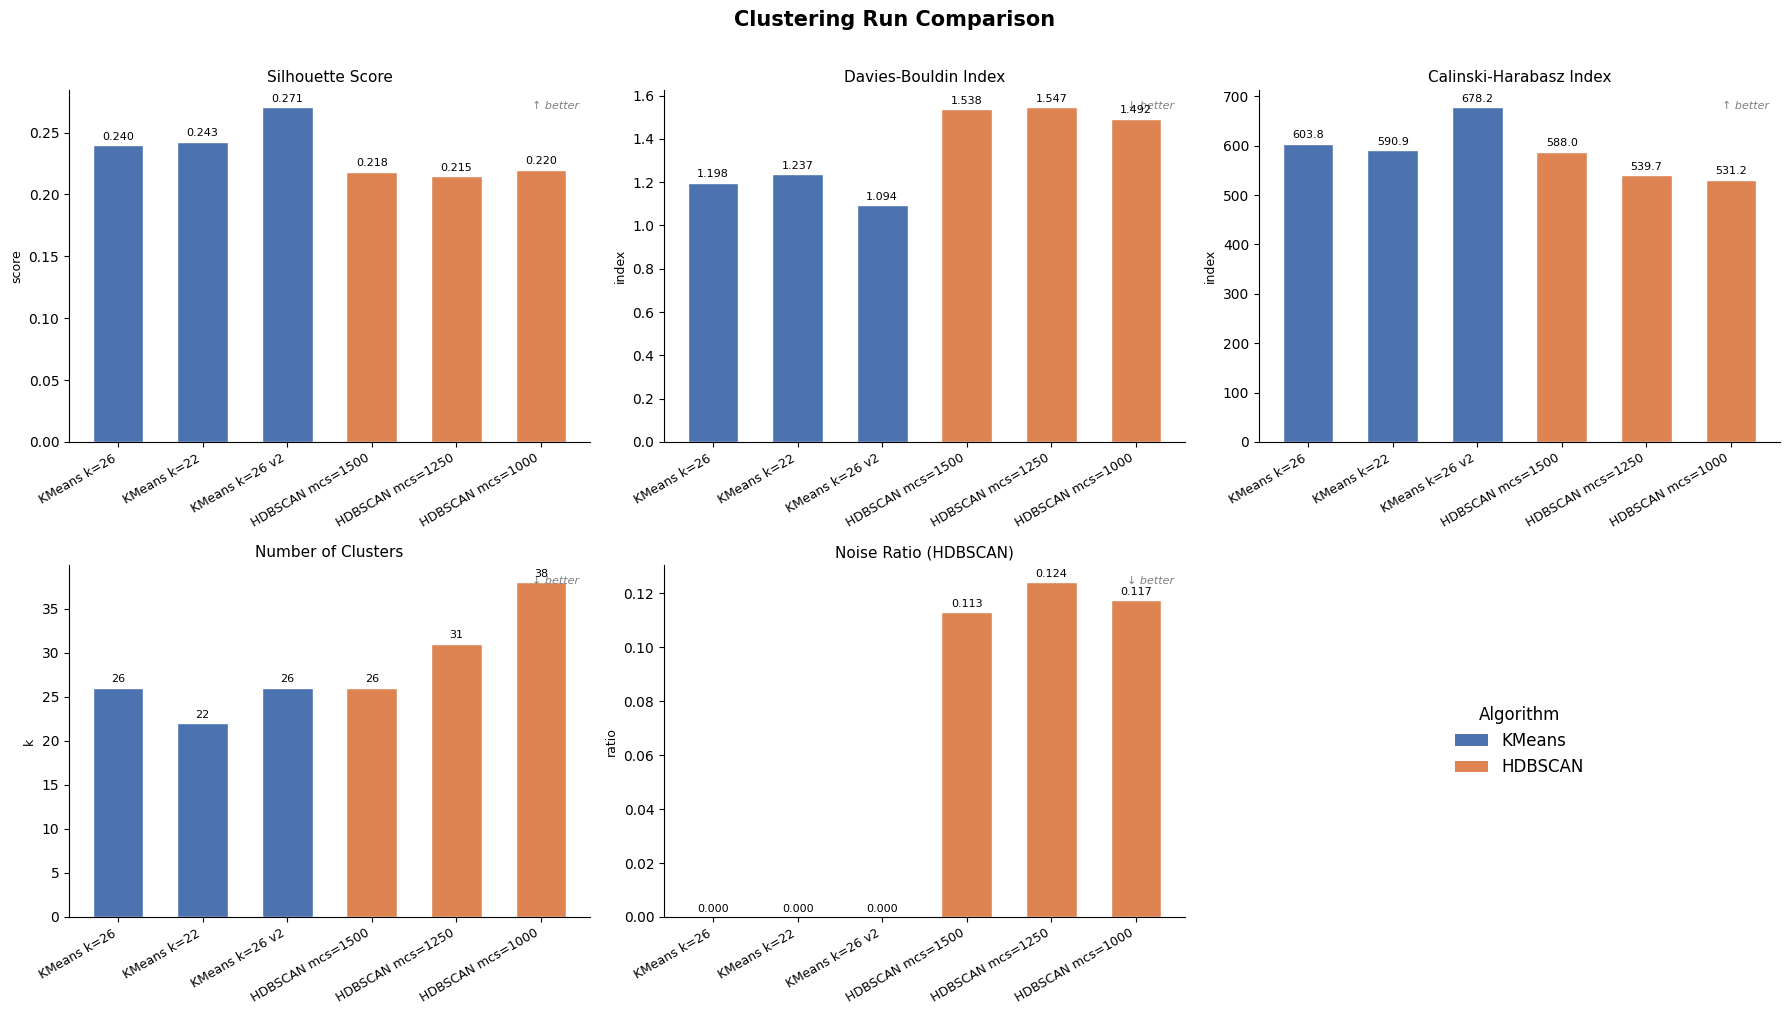

In [20]:
palette = {"kmeans": "#4C72B0", "hdbscan": "#DD8452"}
colors = [palette[m] for m in df_runs["model"]]
labels = df_runs["label"].tolist()
x = np.arange(len(labels))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Clustering Run Comparison", fontsize=15, fontweight="bold", y=1.01)

def bar_ax(ax, values, title, ylabel, higher_better=True, annotate_fmt=".3f"):
    bars = ax.bar(x, values, color=colors, edgecolor="white", width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    arrow = "↑ better" if higher_better else "↓ better"
    ax.text(0.98, 0.97, arrow, transform=ax.transAxes, ha="right", va="top",
            fontsize=8, color="gray", style="italic")
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(values) * 0.01,
                f"{v:{annotate_fmt}}", ha="center", va="bottom", fontsize=8)

bar_ax(axes[0, 0], df_runs["silhouette"].tolist(),       "Silhouette Score",       "score",       higher_better=True)
bar_ax(axes[0, 1], df_runs["davies_bouldin"].tolist(),   "Davies-Bouldin Index",   "index",       higher_better=False)
bar_ax(axes[0, 2], df_runs["calinski_harabasz"].tolist(),"Calinski-Harabasz Index","index",       higher_better=True,  annotate_fmt=".1f")
bar_ax(axes[1, 0], df_runs["n_clusters"].tolist(),       "Number of Clusters",     "k",           higher_better=None,  annotate_fmt=".0f")
bar_ax(axes[1, 1], df_runs["noise_ratio"].tolist(),      "Noise Ratio (HDBSCAN)",  "ratio",       higher_better=False, annotate_fmt=".3f")

# legend
from matplotlib.patches import Patch
axes[1, 2].axis("off")
legend_elements = [Patch(facecolor=palette["kmeans"],  label="KMeans"),
                   Patch(facecolor=palette["hdbscan"], label="HDBSCAN")]
axes[1, 2].legend(handles=legend_elements, loc="center", fontsize=12, frameon=False,
                  title="Algorithm", title_fontsize=12)

plt.tight_layout()
plt.show()

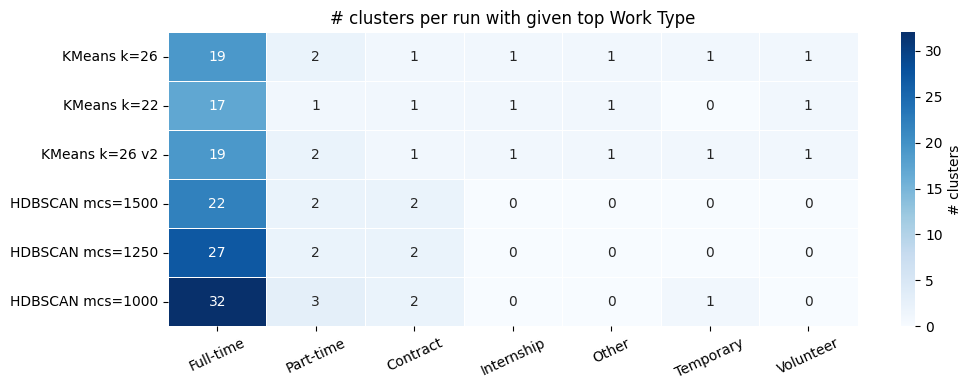

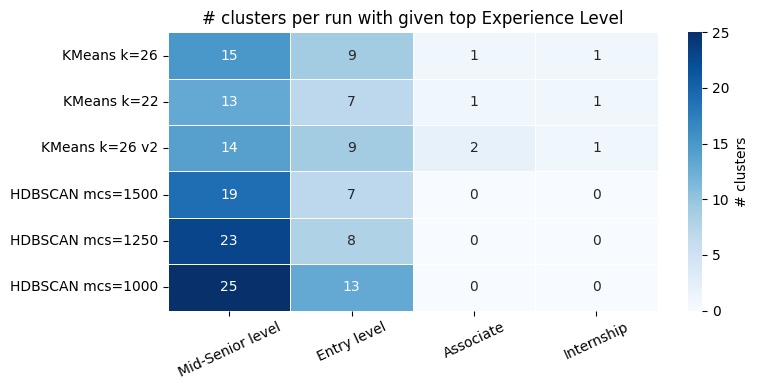

In [22]:
def composition_heatmap(all_summaries, col, title):
    rows = {}
    for run_id, summary in all_summaries.items():
        rows[RUNS[run_id]["label"]] = summary[col].value_counts()

    df_heat = pd.DataFrame(rows).T.fillna(0).astype(int)
    df_heat = df_heat[df_heat.sum().sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(max(8, len(df_heat.columns) * 1.5), 4))
    sns.heatmap(df_heat, annot=True, fmt="d", cmap="Blues", linewidths=0.5,
                linecolor="white", ax=ax, cbar_kws={"label": "# clusters"})
    ax.set_title(f"# clusters per run with given top {title}", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=25)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.show()

composition_heatmap(all_summaries, "top_work_type",  "Work Type")
composition_heatmap(all_summaries, "top_experience", "Experience Level")

### Final Model Selection

Based on the metric comparison and composition heatmaps above, **K-Means consistently outperforms HDBSCAN** on internal validation metrics (silhouette, Davies-Bouldin, Calinski-Harabasz). Beyond raw scores, the K-Means runs also produce more diverse cluster compositions across experience levels and work types, which makes the clusters easier to interpret and label.

Among the K-Means candidates, **K-Means k=26 (v1)** is selected as the final configuration. While the v2 variant (k=26 v2) achieves slightly better metric scores, it was trained without `normalized_salary` as a feature. Since salary is a key dimension for meaningful job market segmentation, dropping it reduces the interpretive value of the resulting clusters. The v1 model retains salary information, making its clusters more actionable.
